# 4 — Full Pipeline Integration

Tests the integrated system with both components (Bingham filter + T³ QAN) on the 2D baseline arena (not running the experiment).

In [1]:
!pip install torch numpy matplotlib
!pip install git+https://github.com/jacobsvennevik/MADE.git

  Cloning https://github.com/jacobsvennevik/MADE.git to /tmp/pip-req-build-fg5b4feg
  Running command git clone --filter=blob:none --quiet https://github.com/jacobsvennevik/MADE.git /tmp/pip-req-build-fg5b4feg
  Resolved https://github.com/jacobsvennevik/MADE.git to commit 1673eeabd571b4815122c3948694fae13de9f039
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached scikit_learn-1.9.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
  Using cached loguru-0.7.3-py3-none-any.whl.metadata (22 kB)
  Using cached pre_commit-4.6.0-py2.py3-none-any.whl.metadata (1.2 kB)
  Using cached black-26.5.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (95 kB)
  Using cached flake8-7.3.0-py2.py3-none-any.whl.metadata (3.8 kB)
  Using cached click-8.4.1-py3-none-any.whl.metadata (2.6 kB)
  Using cached mypy_extensions-1.1.0-py3-none-any.w

In [ ]:
import os
import sys
import time
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from analysis.scoring import autocorr2d, hex_gridness_2d, SMOOTH_SIGMA
from scipy.ndimage import gaussian_filter

sys.path.insert(0, '/workspace/CAN_Path_Integration_3D_model')
#sys.path.insert(0, os.path.abspath("../.."))

from network.visualize3D import visualize_trajectory_projections, plot_pi_error
from experiments.arena_2d import Arena2DExperiment, Arena2DConfig
from analysis.scoring import score_2d
from metrics import wrapped_angle_diff
from config import RunConfig, NetworkConfig, ExperimentConfig
from experiments.arena_2d import Arena2DExperiment
from analysis.scoring import score_2d_from_map, run_and_score_2d
from analysis.visualize3D_fields import standardize_ratemaps
from config import world_to_flat_bins
from plane_estimation import angular_error_s2, plot_bingham_convergence




In [ ]:
# config + experiment
N_STEPS=250_000 
GRID_SPACING = 0.5
RATEMAP_BINS = 40
g_vec = np.array([0., 0., -9.81])
cfg = RunConfig(
    network=NetworkConfig(build_connectivity=False),                 # validated defaults
    experiment=Arena2DConfig(n_steps=N_STEPS, grid_spacing = GRID_SPACING, ratemap_bins=RATEMAP_BINS), # Arena2DConfig → has run_name
)
exp = Arena2DExperiment(cfg, record=False)    # config, not g


[arena_2d] neurons 250,047 arena 2.0 m | grid_spacing 0.5 m | tilings 4.00


## Set up the arena

In [14]:
# run + save
print("Running ...")
t0 = time.time()
result = exp.run_experiment(g=g_vec)
exp.save(result, f"workspace/runs/{cfg.experiment.run_name}.npz")
print(f"Saved runs/{cfg.experiment.run_name}.npz  ({time.time()-t0:.1f}s)")

# everything from the result object (single source of truth)
world_pos  = result.world_pos
torus_gt   = result.torus_gt
theta_hist = result.theta_hist
gap        = result.gap_hist
n_hat_hist = result.n_hat_hist
T          = cfg.experiment.n_steps


print(f"Filter gap  t=100: {gap[99]:.4f}  t=500: {gap[499]:.4f}  t={T}: {gap[-1]:.4f} ")
print(f"n_hat at t={T}: {n_hat_hist[-1]}  (target [0, 0, 1])")
print(f"theta_3 decoded range: [{theta_hist[:, 2].min():.4f}, {theta_hist[:, 2].max():.4f}]  target ~[0, 0]")
print(f"MADE error  full: {result.mean_norm_error:.4f}  after t=200: {result.norm_error[200:].mean():.4f}")

Running ...
Saved runs/arena2d_T300000_kap10.0_seed0_envSize2.0_gridSpacing0.5.npz  (243.3s)
Filter gap  t=100: 506.7748  t=500: 297.4889  t=300000: 1231.5112 
n_hat at t=300000: [0. 0. 1.]  (target [0, 0, 1])
theta_3 decoded range: [3.1416, 3.1416]  target ~[0, 0]
MADE error  full: 0.0160  after t=200: 0.0158


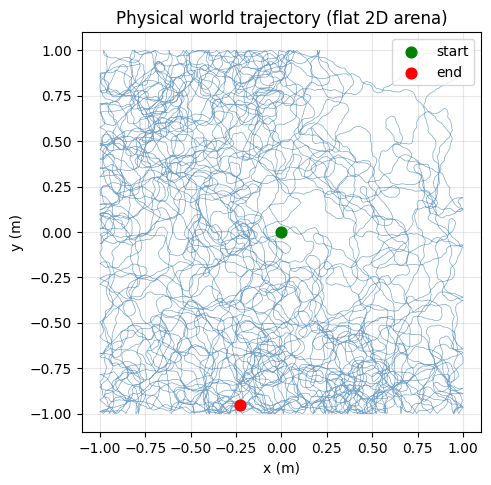

In [15]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(world_pos[:, 0], world_pos[:, 1], lw=0.5, alpha=0.7, color="steelblue")
ax.scatter(*world_pos[0, :2],  color="green", s=60, zorder=5, label="start")
ax.scatter(*world_pos[-1, :2], color="red",   s=60, zorder=5, label="end")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_title("Physical world trajectory (flat 2D arena)")
ax.set_aspect("equal")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


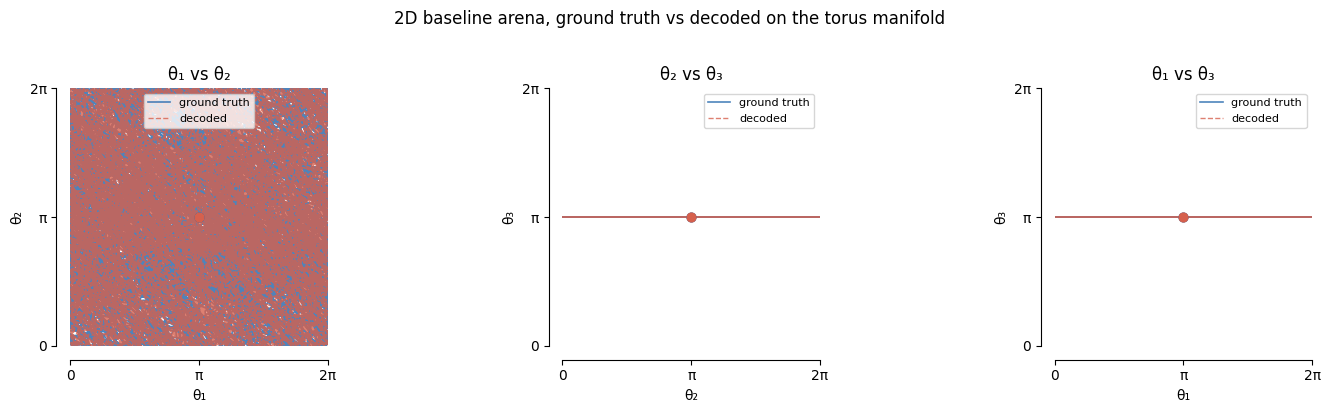

In [16]:
fig, _ = visualize_trajectory_projections(
    torus_gt, theta_hist,
    title="2D baseline arena, ground truth vs decoded on the torus manifold",
)
plt.show()


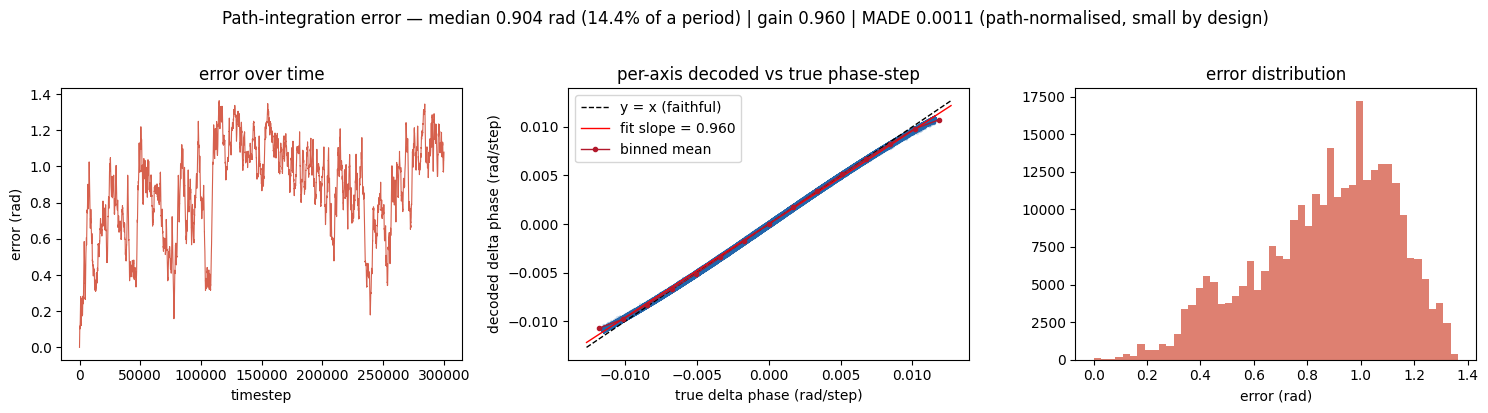

In [17]:
fig, _ = plot_pi_error(torus_gt, theta_hist)
plt.show()

Visualize the angular error of the bingham filter

(<Figure size 800x550 with 2 Axes>,
 array([<Axes: ylabel='angular error (deg)'>,
        <Axes: title={'center': 'Filter concentration (larger gap = more committed)'}, xlabel='time step', ylabel='certainty  z₂−z₁'>],
       dtype=object))

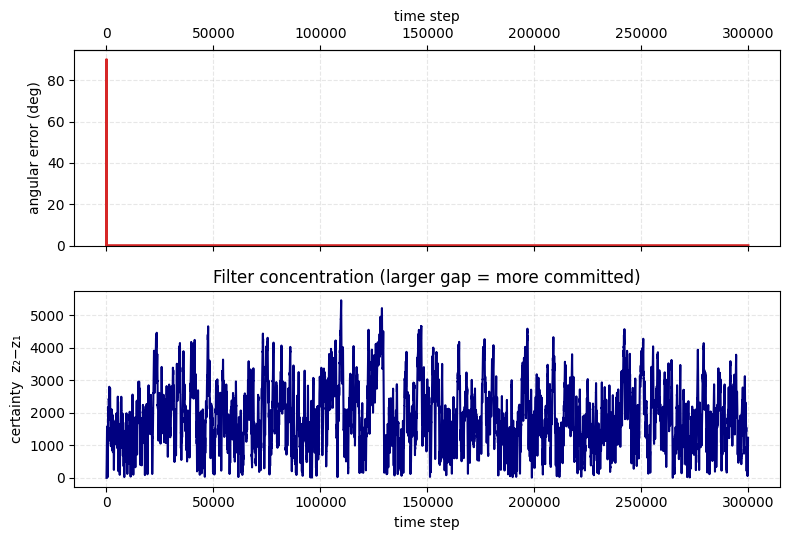

In [18]:
n_true = -g_vec / np.linalg.norm(g_vec)       #the correct gravity vector

plot_bingham_convergence(n_hat_hist, gap,  n_true)

Create oracle map, with perfect CAN movement to see what it produces

In [19]:
bins = cfg.experiment.ratemap_bins
flat_indices = world_to_flat_bins(world_pos, cfg.experiment.env_size, bins)  # same array the harness built

bk  = exp.last_integrator.backend     # real map is already in `result`, so reusing/mutating this is safe
acc = bk.allocate_ratemap(bins ** 2)
for t in range(len(torus_gt)):
    bk.reset(torus_gt[t], radius=0.25)
    bk.record_ratemap(acc, int(flat_indices[t]))
sums_or, counts_or = bk.ratemap_to_numpy(acc, bins)

In [20]:
def _report(tag, sums, counts, active_mask):
    r = score_2d_from_map(sums, counts, active_mask=active_mask)
    gl = r["grid_like"]
    print(f"{tag}: occ {r['occupancy']:.0%} | ring {r['ring_frac']:.0%} | "
          f"grid-like {gl.sum()}/{r['n_active']} ({100*gl.mean():.1f}%) | "
          f"median HGS {np.nanmedian(r['hgs']):.3f}")
    print(f"       SGS≥HGS (square confusion): "
          f"{(np.isfinite(r['sgs']) & (r['sgs'] >= r['hgs'])).sum()} cells")
    return r

out_real   = _report("real  ", result.ratemap_sums, result.ratemap_counts, result.active_mask)
out_oracle = _report("oracle", sums_or, counts_or, result.active_mask)


real  : occ 93% | ring 100% | grid-like 63/66 (95.5%) | median HGS 1.082
       SGS≥HGS (square confusion): 0 cells
oracle: occ 93% | ring 36% | grid-like 23/66 (34.8%) | median HGS 1.076
       SGS≥HGS (square confusion): 0 cells


scored cells: 66 / 300


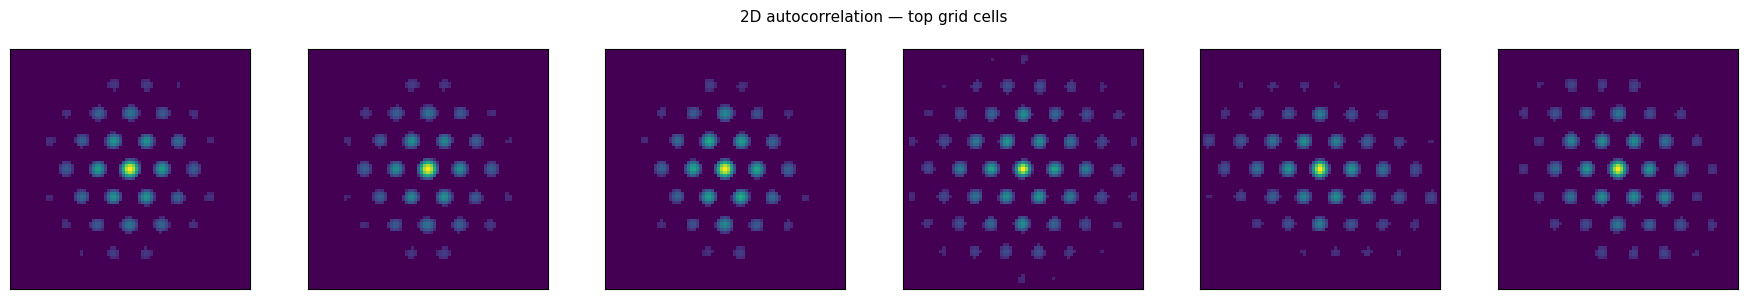

In [21]:
ac         = out_real["ac"]          # (2*bins-1, 2*bins-1, n_scored) needs ac=ac in the return
hgs        = out_real["hgs"]         # (n_scored,)
scored_idx = out_real["scored_idx"]  # indices into the SCORED columns, not neuron IDs
true_id    = result.sub_idx[scored_idx]   # subsample-column → real neuron index in full N

finite = np.flatnonzero(np.isfinite(hgs))      # indices with a real score
order  = finite[np.argsort(hgs[finite])[::-1]] # those, sorted high→low
top    = order[:6]

print("scored cells:", int(result.active_mask.sum()), "/", result.active_mask.size)
if top.size == 0:
    print("No cells with a finite HGS to plot.")
else:
    fig, axes = plt.subplots(1, top.size, figsize=(3 * top.size, 3), squeeze=False)
    for ax, k in zip(axes[0], top):
        ax.imshow(ac[:, :, k].T, origin="lower", cmap="viridis")
        ax.set_xticks([]); ax.set_yticks([])
    plt.suptitle("2D autocorrelation — top grid cells", fontsize=11)
    plt.tight_layout(); plt.show()

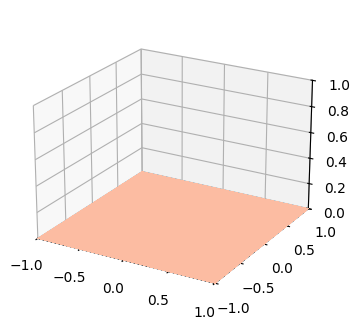

In [12]:
rate, _ = standardize_ratemaps(result.ratemap_sums, result.ratemap_counts)

cell = 0
m = rate[..., cell]
bins = m.shape[0]
c = np.linspace(-1, 1, bins)
X, Y = np.meshgrid(c, c)
Z = np.nan_to_num(m.T, nan=0.0)

fig = plt.figure(figsize=(4.5, 4))
ax = fig.add_subplot(111, projection="3d")
xy = result.world_pos[:, :2] / np.nanmax(np.abs(result.world_pos[:, :2]))
ax.plot(xy[:, 0], xy[:, 1], 0*xy[:, 0], color="#8fb3e6", lw=0.3, alpha=0.5)
ax.contourf(X, Y, Z, levels=12, cmap="Reds", offset=0, zdir="z")
ax.set_xlim(-1, 1); ax.set_ylim(-1, 1); ax.set_zlim(0, 1)
ax.set_box_aspect((1, 1, 0.7)); ax.view_init(elev=22, azim=-60)
plt.show()

In [ ]:
bins = (out_real["ac"].shape[0] + 1) // 2      # ac is (2*bins-1, 2*bins-1, n) -> recover bins
rng  = np.random.default_rng(0)

def _random_floor(n_maps=200):
    """Mean 2D HGS of random rate maps, smoothed + scored exactly like the cells."""
    vals = []
    for _ in range(n_maps):
        m  = gaussian_filter(rng.random((bins, bins)), sigma=SMOOTH_SIGMA)  # match cell smoothing
        h, _ = hex_gridness_2d(autocorr2d(m)[..., 0])
        if np.isfinite(h):
            vals.append(h)
    return float(np.mean(vals)) if vals else np.nan

floor   = _random_floor()
ceiling = float(np.nanmedian(out_oracle["hgs"]))   # best this network can do (perfect PI)
median  = float(np.nanmedian(out_real["hgs"]))     # the filtered model
X       = (median - floor) / (ceiling - floor)

print(f"median HGS (real)   : {median:.3f}")
print(f"random floor (mean) : {floor:.3f}")
print(f"oracle ceiling (med): {ceiling:.3f}")
print(f"-> {X:.0%} of the way from random floor to oracle ceiling")